## Here we compare the model trained without functional profiles of Orbito-frontal region (yeo network 10) with full model

In [1]:
import numpy as np
import pandas as pd
import nibabel as nb
import Functional_Fusion.dataset as fdata # from functional fusion module
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.data as cdata
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.summarize as cs
import cortico_cereb_connectivity.scripts.script_summarize_weights as cssw
import matplotlib.pyplot as plt
import seaborn as sns
import Functional_Fusion.atlas_map as am
import nitools as nt
import SUITPy as suit
import contextlib
import os
import warnings
from copy import deepcopy

In [2]:
traindata_list = gl.get_ldo_names()
parcellation = 'Icosahedron1002'
method = 'NNLS'

yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_{parcellation}.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
label_dict = yeo_img.header.get_axis(0).label[0]
atlas,ainf = am.get_atlas('MNISymC3')

colors = [label_dict[i+1][1] for i in range(17)]
names = [label_dict[i+1][0] for i in range(17)]
reg_size = [np.sum(yeo_data == i+1) for i in range(17)]

In [3]:
def create_empty_df():
    full_df = pd.DataFrame(columns=[
        'train_ds',
        'eval_ds',
        'eval_subj',
        'method',
        'net_id',
        'net_name',
        'net_color',
        'net_size',
        'net_sum_weights',
        'exclude_net_performance',
        'full_performance'
    ])
    return full_df

def get_model_performance(conn_model, train_info, ev_ds, ev_ses):
    model_config = rm.get_model_config()
    model_config['model'] = [conn_model]
    model_config['train_info'] = [train_info]
    eval_config = rm.get_eval_config(eval_dataset=ev_ds, eval_ses=ev_ses, cerebellum='MNISymC3', parcellation='Icosahedron1002')
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            df, _ = rm.eval_model(None, None, eval_config, model_config)
    return df

### Load full/altered model and evaluate on held-out dataset


In [ ]:
full_df = create_empty_df()

for t, td in enumerate(traindata_list):
    ed = gl.datasets[t]
    es = gl.sessions[t]
    print(f'Train: {td}, Eval: {ed}')
    base_conn_model, train_info = cs.get_model(td, parcellation, method, extension='A0_global')

    X = nb.load(gl.conn_dir + f"/maps/{td}_data_cortex.pscalar.nii").get_fdata()
    normalized_coef = base_conn_model.coef_ * np.sqrt(np.nansum(X**2, axis=0))
    total_weights = [np.nansum(normalized_coef[:, yeo_data == i+1]) for i in range(17)]

    # evaluate full model
    base_df = get_model_performance(base_conn_model, train_info, ed, es)
    base_df = base_df.rename(columns={'eval_dataset': 'eval_ds', 'R_eval': 'full_performance'})

    for i in range(17):
        print(f'   - Performance of ablationed model without: {label_dict[i+1][0]}')

        # load ablation
        conn_model, train_info = cs.get_model(td, parcellation, method, extension=f'no-yeo{i+1}_A0_global')

        # evaluate ablation model
        df = get_model_performance(conn_model, train_info, ed, es)

        # df
        df_subset = df[['eval_dataset', 'eval_subj', 'R_eval']].copy()
        df_subset = df_subset.rename(columns={'eval_dataset': 'eval_ds', 'R_eval': 'exclude_net_performance'})
        df_subset['train_ds'] = td
        df_subset['method'] = method
        df_subset['net_id'] = i+1
        df_subset['net_name'] = label_dict[i+1][0]
        df_subset['net_color'] = [label_dict[i+1][1]] * len(df_subset)
        df_subset['net_size'] = np.nansum(yeo_data == i+1)
        df_subset['net_sum_weights'] = total_weights[i]
        df_subset = df_subset.merge(base_df[['eval_ds', 'eval_subj', 'full_performance']], on=['eval_ds', 'eval_subj'], how='left')
        df_subset['rel_performance'] = (df_subset['exclude_net_performance']-df_subset['full_performance'])/df_subset['full_performance']*100
        df_subset = df_subset[['train_ds', 'eval_ds', 'eval_subj', 'method', 'net_id', 'net_name', 'net_color',
                               'net_size', 'net_sum_weights', 'exclude_net_performance', 'full_performance', 'rel_performance']]
        full_df = pd.concat([full_df, df_subset], ignore_index=True)

full_df.to_csv('../../tsv/exclude_train_df.tsv', sep='\t', index=False)

Train: WfIbDeHtNiSoScLa, Eval: MDTB
   - Performance of ablationed model without: 01.VisualA
   - Performance of ablationed model without: 02.VisualB
   - Performance of ablationed model without: 03.SomatomotorA
   - Performance of ablationed model without: 04.SomatomotorB
   - Performance of ablationed model without: 05.DorsalAttentionA
   - Performance of ablationed model without: 06.DorsalAttentionB
   - Performance of ablationed model without: 07.VentralAttentionA
   - Performance of ablationed model without: 08.VentralAttentionB
   - Performance of ablationed model without: 09.LimbicA
   - Performance of ablationed model without: 10.LimbicB
   - Performance of ablationed model without: 11.ControlC
   - Performance of ablationed model without: 12.ControlA
   - Performance of ablationed model without: 13.ControlB
   - Performance of ablationed model without: 14.TemporalParietal
   - Performance of ablationed model without: 15.DefaultC
   - Performance of ablationed model without: 16

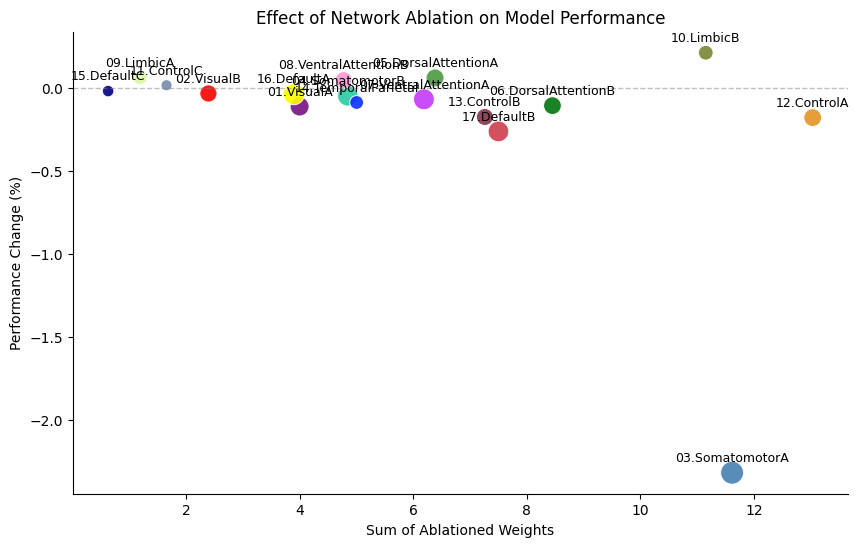

In [5]:
colors = [label_dict[i+1][1] for i in range(17)]
names = [label_dict[i+1][0] for i in range(17)]

# read file
full_df = pd.read_csv('../../tsv/exclude_train_df.tsv', sep="\t")

# aggregate across subjects
piv_df = full_df.groupby(['net_name', 'eval_ds'], as_index=False).agg(
        net_sum_weights=('net_sum_weights', 'mean'),
        net_size=('net_size', 'mean'),
        rel_perf_mean=('rel_performance', 'mean'),
        rel_perf_median=('rel_performance', 'median')
)

# aggregate across datasets
summary_df = piv_df.groupby('net_name').agg(
    net_sum_weights=('net_sum_weights', 'mean'),
    net_size=('net_size', 'mean'),
    rel_perf_mean=('rel_perf_mean', 'mean'),
    rel_perf_median=('rel_perf_median', 'median')
).reset_index()
summary_df.net_sum_weights = summary_df.net_sum_weights / summary_df.net_sum_weights.sum() * 100

# figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
sizes = summary_df["net_size"]*1.5

sns.scatterplot(data=summary_df,
                x='net_sum_weights',
                y='rel_perf_median',
                s=sizes,
                color=colors,
                alpha=0.9,
                ax=ax)

for _, row in summary_df.iterrows():
    ax.text(row["net_sum_weights"], row["rel_perf_median"] + 0.05, row["net_name"], fontsize=9, ha="center", va="bottom")

ax.set_xlabel("Sum of Ablationed Weights")
ax.set_ylabel("Performance Change (%)")
ax.set_title("Effect of Network Ablation on Model Performance")
sns.despine()

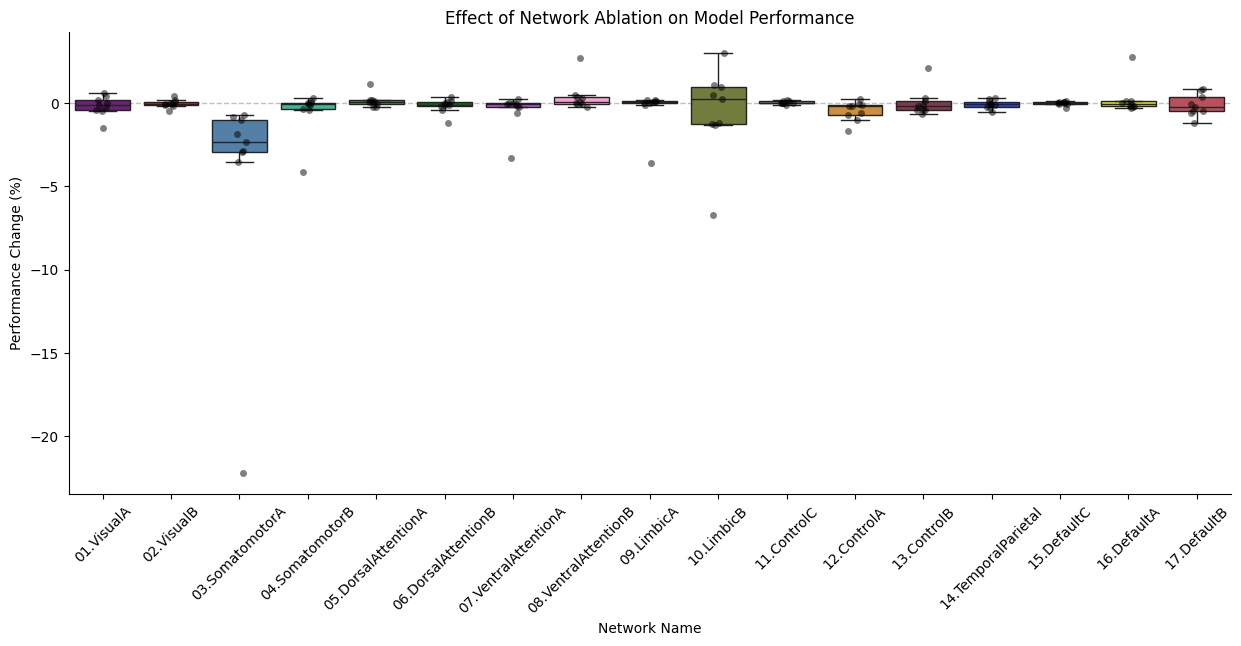

In [44]:
# figure
fig, ax = plt.subplots(figsize=(15, 6))
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
sizes = piv_df["net_size"]*1.5

sns.boxplot(
    data=piv_df,
    x='net_name',
    y='rel_perf_median',
    hue='net_name', palette=colors,
    # fill=False,
    ax=ax,
    showfliers=False
)

sns.stripplot(
    data=piv_df,
    x='net_name',
    y='rel_perf_median',
    # hue="eval_ds", palette="tab10",
    color='black', alpha=0.5,
    jitter=True,
    size=5,
    ax=ax
)

ax.set_xlabel("Network Name")
ax.set_ylabel("Performance Change (%)")
ax.set_title("Effect of Network Ablation on Model Performance")
ax.tick_params(axis='x', rotation=45)
sns.despine()

`03.SomatomotorA` and `10.LimbicB` show the highest variance across evaluation datasets. Specifically, the `Somatotopic` dataset causes the most performance change in these two networks. Notably, the `MDTB` seems to benefit from `10.LimbicB` ablation, as well as `Nishimoto` and `Social`.

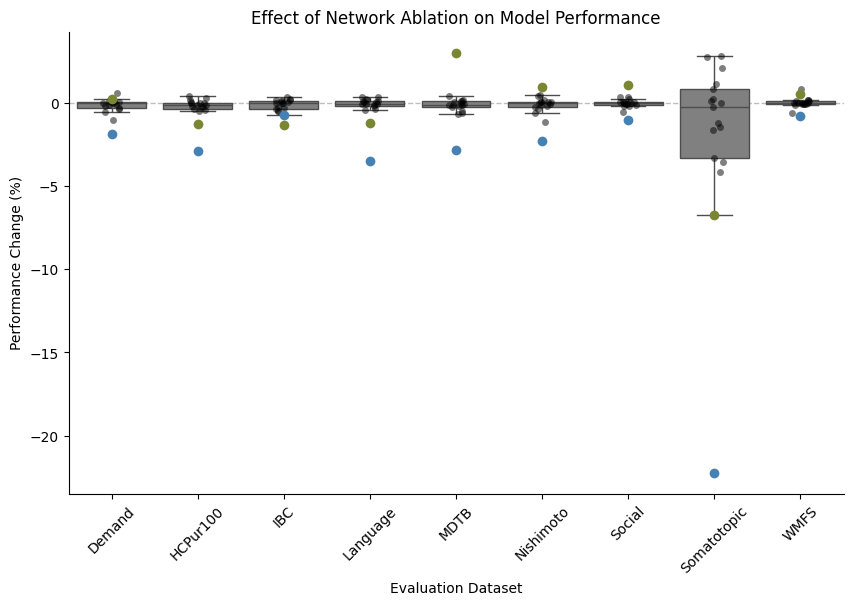

In [51]:
# figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
sizes = piv_df["net_size"]*1.5

sns.boxplot(
    data=piv_df,
    x='eval_ds',
    y='rel_perf_median',
    color='gray',
    ax=ax,
    showfliers=False
)

sns.stripplot(
    data=piv_df[~piv_df['net_name'].isin(['03.SomatomotorA', '10.LimbicB'])],
    x='eval_ds',
    y='rel_perf_median',
    ax=ax,
    color='black',
    alpha=0.5,
    jitter=True,
    size=5
)

# highlight the SomatomotorA network
sns.stripplot(data=piv_df[piv_df['net_name']=='03.SomatomotorA'],
    x='eval_ds', y='rel_perf_median',
    color=colors[2], jitter=True, ax=ax, size=7)

# highlight the LimbicB network
sns.stripplot(data=piv_df[piv_df['net_name']=='10.LimbicB'],
    x='eval_ds', y='rel_perf_median',
    color=colors[9], jitter=True, ax=ax, size=7)

ax.set_xlabel("Evaluation Dataset")
ax.set_ylabel("Performance Change (%)")
ax.set_title("Effect of Network Ablation on Model Performance")
ax.tick_params(axis='x', rotation=45)
sns.despine()

`Somatotopic` causes the most variation from the full model performance across networks. Predictions on `Somatotopic` are sensitive to ablations. The drops on each evaluation dataset is always caused by `03.SomatomotorA`

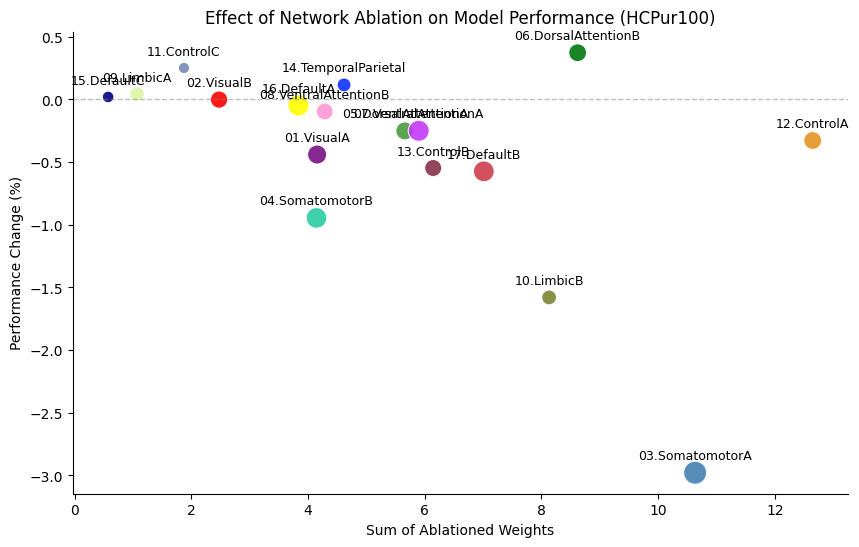

In [42]:
# replication on HCP
ev_ds = 'HCPur100'
sub_df = full_df[full_df['eval_ds'] == ev_ds]
piv_df = sub_df.groupby(['net_id', 'net_name'], as_index=False).agg({
        'net_sum_weights': 'mean',
        'net_size': 'mean',
        'rel_performance': 'mean',
})
piv_df["net_color"] = piv_df["net_id"].map(lambda x: label_dict[int(x)][1])

# figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
sizes = piv_df["net_size"]*1.5

sns.scatterplot(data=piv_df,
                x='net_sum_weights',
                y='rel_performance',
                s=sizes,
                color=colors,
                alpha=0.9,
                ax=ax)

for _, row in piv_df.iterrows():
    ax.text(row["net_sum_weights"], row["rel_performance"] + 0.08, row["net_name"], fontsize=9, ha="center", va="bottom")

ax.set_xlabel("Sum of Ablationed Weights")
ax.set_ylabel("Performance Change (%)")
ax.set_title(f"Effect of Network Ablation on Model Performance ({ev_ds})")
sns.despine()

The drop on HCP was real, but only by luck.